# 13. Three-Dimensional Tidal Maps

Notebook 9 mapped the secular tidal heating of a homogeneous, strongly dissipative Io. This notebook shows how that map changes with eccentricity, spin, and obliquity. It then maps the time-resolved response: the stress through one orbit, the largest tension over an orbit, the stress-strain loop that shows dissipation, and the surface displacement.

The maps are drawn by `plot_map` and `make_map_axes` from `TidalPy.Utilities.graphics`. They use cartopy projections when cartopy is installed (optional `graphics` extra), and matplotlib's Mollweide projection otherwise.

In [1]:
%matplotlib inline
import os
import time

import numpy as np
# The trapezoid rule: np.trapezoid from NumPy 2.0, np.trapz before it.
trapezoid = getattr(np, "trapezoid", None) or np.trapz
import matplotlib.pyplot as plt

from TidalPy.Material import Material, Phase, make_eos, make_shear_modulus
from TidalPy.Rheology import Maxwell
from TidalPy.Structures import GasGiantWorld, Layer, System, TerrestrialWorld, make_tide
from TidalPy.Utilities.graphics import make_map_axes, plot_map
from TidalPy.Viscosity import make_viscosity

R = 1.8216e6
M = 8.9319e22
RHO = M / (4.0 / 3.0 * np.pi * R**3)
M_JUP = 1.898e27
A_IO = 4.217e8
E_IO = 0.0041


def build_io(shear_viscosity):
    """The homogeneous Maxwell Io of notebook 9 with a chosen shear viscosity [Pa s], in a system with Jupiter."""
    world = TerrestrialWorld("Io", R, M)
    # A uniform rock: constant density, shear modulus, and viscosities (the bulk viscosity is high enough to be elastic)
    mantle_rock = Phase(
        eos=make_eos("constant", {"reference_density_kg_m3": RHO, "bulk_modulus_pa": 200.0e9}),
        shear_modulus=make_shear_modulus("constant", {"shear_modulus_pa": 60.0e9}),
        shear_viscosity=make_viscosity("constant", {"reference_viscosity_pas": shear_viscosity}),
        bulk_viscosity=make_viscosity("constant", {"reference_viscosity_pas": 1.0e30}))
    world.add_layer(Layer(
        "mantle",
        radius_outer=R,
        material=Material(solid=mantle_rock),
        shear_rheology=Maxwell(),
        bulk_rheology=Maxwell()))
    world.set_tide_model(make_tide("rheology"))
    world.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=2, obliquity_truncation=0)
    world.solve_eos(temperature=1500.0, raise_on_fail=True)
    # The system supplies Io's orbital state to every tidal call; Jupiter needs no interior
    system = System("Jupiter-Io")
    system.add_world(GasGiantWorld("Jupiter", 6.9911e7, M_JUP))
    system.add_world(world, tidal_host="Jupiter", semi_major_axis=A_IO, eccentricity=E_IO, synchronous=True)
    return world, system


io, io_system = build_io(1.0e15)
N_MOTION = io.get_tide_state()["orbital_frequency"]   # Mean motion [rad s-1]
PERIOD = 2.0 * np.pi / N_MOTION                        # Orbital period [s]

longitudes = np.linspace(0.0, 2.0 * np.pi, 121)       # [rad]
colatitudes = np.linspace(0.02, np.pi - 0.02, 61)     # [rad]
equator = np.argmin(np.abs(colatitudes - 0.5 * np.pi))
surface = 0.99 * R                                    # Just below the surface [m]
print("Io built and EOS solved:", io.eos_solved)

Io built and EOS solved: True


## Heating Across Orbital Configurations

The world's tide config sets which tidal modes are included: the harmonic degree range and the eccentricity and obliquity truncation levels. The orbital state of each call sets the eccentricity, spin, and obliquity values: an argument given to the call replaces that value of the system's state for the call alone. `temporary_tide_config` raises the truncation levels for one map and restores the previous ones afterward. The four maps show the secular heating just below the surface, each on its own log scale.

Synchronous, e = 0.0041            strongest 4.69e-06 W/m^3, weakest 1.73e-07 W/m^3, north-south difference 0.0% of the peak
Synchronous, e = 0.1               strongest 2.83e-03 W/m^3, weakest 1.11e-04 W/m^3, north-south difference 0.0% of the peak
Spin = 1.2 n, e = 0.0041           strongest 2.22e-02 W/m^3, weakest 3.43e-03 W/m^3, north-south difference 0.0% of the peak
Synchronous, obliquity = 0.1 rad   strongest 4.47e-04 W/m^3, weakest 1.37e-06 W/m^3, north-south difference 16.2% of the peak


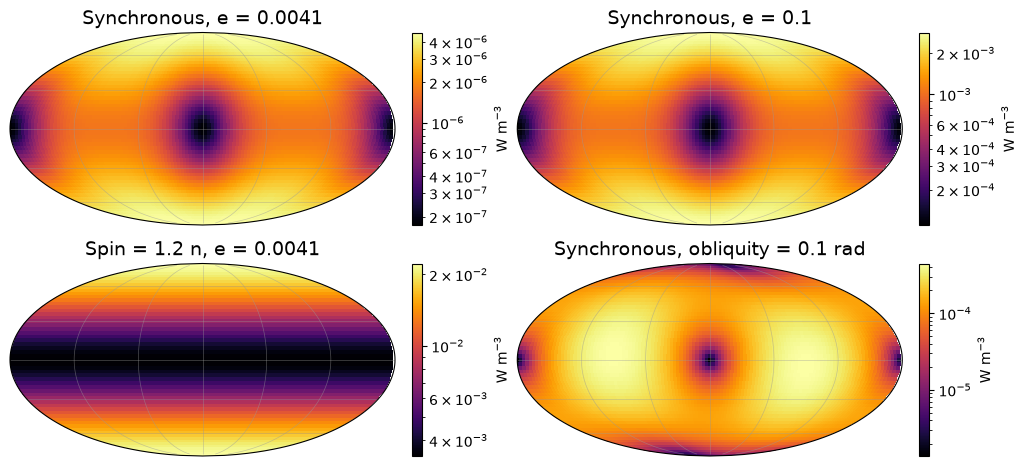

In [2]:
cases = [
    ("Synchronous, e = 0.0041", 2, 0, {}),
    ("Synchronous, e = 0.1", 10, 0, {"eccentricity": 0.1}),
    ("Spin = 1.2 n, e = 0.0041", 2, 0, {"spin_frequency": 1.2 * N_MOTION}),
    ("Synchronous, obliquity = 0.1 rad", 2, 2, {"obliquity": 0.1}),
]

figure, axes = make_map_axes(nrows=2, ncols=2, figure_size=(12.0, 5.5))
for axis, (label, eccentricity_truncation, obliquity_truncation, changes) in zip(axes.flat, cases):
    # Truncation levels high enough for the eccentricity and obliquity of this case
    with io.temporary_tide_config(eccentricity_truncation=eccentricity_truncation,
                                  obliquity_truncation=obliquity_truncation):
        heating = io.calc_3d_tides(radii=np.array([surface]), colatitudes=colatitudes, longitudes=longitudes,
                                   **changes)["heating"][0]
    plot_map(longitudes, colatitudes, heating, axis=axis, log_scale=True, title=label, colorbar_label="W m$^{-3}$")
    asymmetry = np.abs(heating - heating[::-1]).max() / heating.max()
    print(f"{label:34} strongest {heating.max():.2e} W/m^3, weakest {heating.min():.2e} W/m^3, "
          f"north-south difference {asymmetry:.1%} of the peak")
plt.show()

Both synchronous maps share one pattern. The heating is weakest on the equator at the sub-host and anti-host meridians (0 and 180 degrees) and strongest toward the poles. Raising the eccentricity from 0.0041 to 0.1 increases it by about 600, close to the squared eccentricity ratio, since the heating scales with the square of the tidal forcing.

At a spin of 1.2 times the mean motion, the largest tidal mode (static at synchronous rotation) oscillates in the rotating frame, and the heating becomes nearly 5000 times stronger. The heating also no longer depends on longitude. Waves with different longitude structure no longer share a frequency, so their cross terms average out over time.

At synchronous rotation an obliquity of 0.1 rad raises the peak heating about 95 times above the eccentricity-only map. Obliquity adds modes of order $m = 1$, which raise the equatorial heating around 90 and 270 degrees. Together with the eccentricity tide they also break the north-south symmetry: the hemispheres differ by up to 16 percent of the peak. That asymmetry is a cross term of the two tides, proportional to the eccentricity times the obliquity (it vanishes at $e = 0$). Its size and sign depend on the argument of periapsis, which the 3D calculation fixes at zero: the host passes its ascending node and periapse together at $t = 0$.

## Stress Through an Orbit

`calc_3d_stress_strain` returns the instantaneous stress \[Pa\] and strain on a radius, colatitude, longitude, and time grid, with the six tensor components on the last axis (order given by `components`). Here it samples one orbit from periapse at 24 times, just below the surface. The maps show the north-south normal stress at four of these times on a shared color scale. Tension is positive.

components: ('rr', 'theta_theta', 'phi_phi', 'r_theta', 'r_phi', 'theta_phi')
largest magnitude of each component over the orbit [kPa]: [ 4.4 82.2 82.1  3.   4.  77.1]


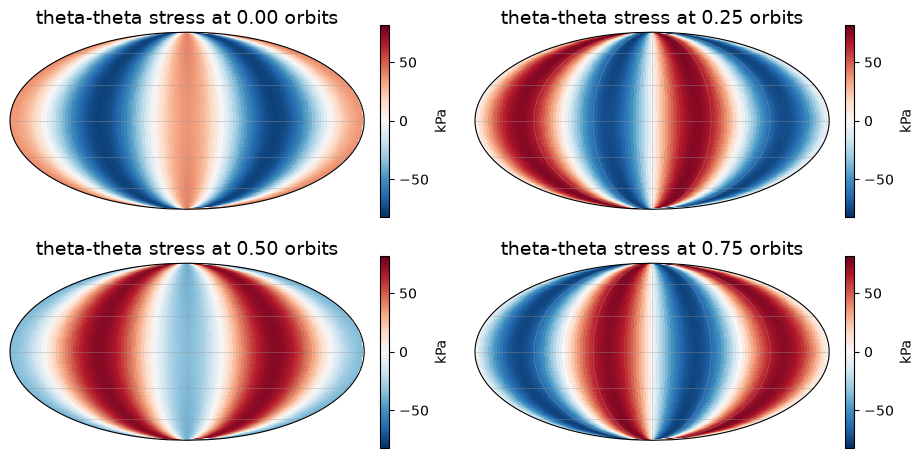

In [3]:
times = np.linspace(0.0, PERIOD, 24, endpoint=False)   # One orbit from periapse [s]
tensors = io.calc_3d_stress_strain(radii=[surface], colatitudes=colatitudes, longitudes=longitudes, times=times)
stress = tensors["stress"][0]   # (colatitude, longitude, time, component) [Pa]
print("components:", tensors["components"])
print("largest magnitude of each component over the orbit [kPa]:",
      np.round(np.abs(stress).max(axis=(0, 1, 2)) / 1.0e3, 1))

theta_theta = stress[..., 1] / 1.0e3   # [kPa]
limit = np.abs(theta_theta).max()
figure, axes = make_map_axes(nrows=2, ncols=2, figure_size=(11.0, 5.5))
for axis, time_index in zip(axes.flat, (0, 6, 12, 18)):
    plot_map(longitudes, colatitudes, theta_theta[:, :, time_index], axis=axis, value_limits=(-limit, limit),
             colormap="RdBu_r", title=f"theta-theta stress at {times[time_index] / PERIOD:.2f} orbits",
             colorbar_label="kPa")
plt.show()

The radial and radial-shear components stay below 5 kPa, compared to approx. 80 kPa for the horizontal ones. The surface is traction-free, so the stress just below it is nearly horizontal. The pattern changes shape through the orbit and reverses sign after half an orbit.

## Largest Tensile Stress

Studies of tidal fracturing need the largest tension a point experiences during an orbit. The principal stresses are the eigenvalues of the stress tensor, so the largest eigenvalue at each point and time is the largest tension there. Its maximum over the orbit gives a single map.

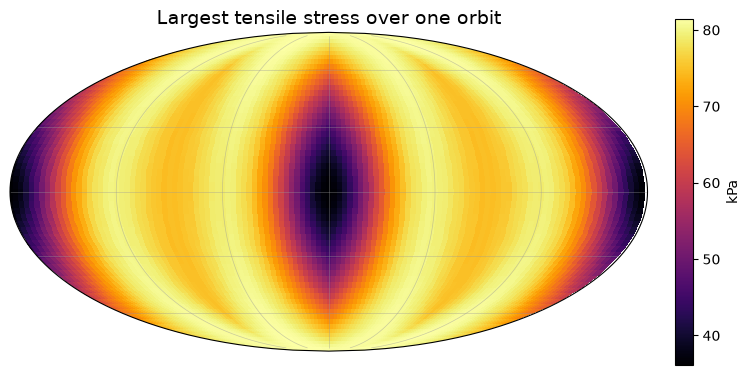

weakest 36 kPa (equator at longitude 0: 36 kPa), strongest 82 kPa (equator at longitude 90: 75 kPa, north pole: 81 kPa)


In [4]:
rr, tt, pp, rt, rp, tp = (stress[..., index] for index in range(6))
tensor = np.stack([
    np.stack([rr, rt, rp], axis=-1),
    np.stack([rt, tt, tp], axis=-1),
    np.stack([rp, tp, pp], axis=-1)], axis=-2)   # (colatitude, longitude, time, 3, 3)
largest_tension = np.linalg.eigvalsh(tensor)[..., -1].max(axis=-1) / 1.0e3   # Largest over the orbit [kPa]

plot_map(longitudes, colatitudes, largest_tension, title="Largest tensile stress over one orbit", colorbar_label="kPa")
plt.show()
print(f"weakest {largest_tension.min():.0f} kPa (equator at longitude 0: {largest_tension[equator, 0]:.0f} kPa), "
      f"strongest {largest_tension.max():.0f} kPa (equator at longitude 90: {largest_tension[equator, 30]:.0f} kPa, "
      f"north pole: {largest_tension[0, 0]:.0f} kPa)")

The largest tension over the orbit is weakest, about 36 kPa, on the equator at the sub-host and anti-host meridians. It reaches 75 kPa on the equator at 90 degrees longitude and 81 kPa at the poles.

## Where Dissipation Appears

Over an orbit each stress component averages to zero, even in this strongly dissipative mantle. Dissipation appears instead as a lag of the strain behind the stress. At one point, a stress component plotted against its strain over one orbit traces a loop, and the loop's area is the work done on the material by that component. In a nearly elastic mantle (viscosity $10^{22}$ \[Pa s\] instead of $10^{15}$) the same point traces almost a straight line.

Summing the loop areas of all six components (shear components counted twice, as in $\sigma : \epsilon$) gives the energy dissipated per unit volume in one orbit. This equals the mean power from `calc_3d_tides` times the orbital period.

Viscosity 1e15 Pa s: mean stress over the orbit 3e-16 of the peak; work per orbit 1.2873e+00 J/m^3; mean power times period 1.2872e+00 J/m^3
Viscosity 1e22 Pa s: mean stress over the orbit 1e-16 of the peak; work per orbit 1.2826e-07 J/m^3; mean power times period 1.2825e-07 J/m^3


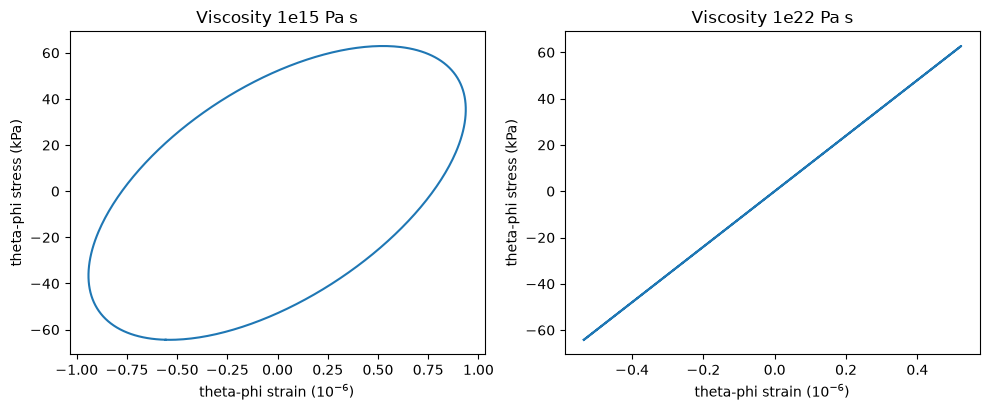

In [5]:
elastic_io, elastic_system = build_io(1.0e22)
point = dict(radii=[0.8 * R], colatitudes=[0.25 * np.pi], longitudes=[0.25 * np.pi])
loop_times = np.linspace(0.0, PERIOD, 401)              # Both ends included, so each loop closes
weights = np.array([1.0, 1.0, 1.0, 2.0, 2.0, 2.0])      # Shear components count twice

figure, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for axis, (label, world) in zip(axes, (("Viscosity 1e15 Pa s", io), ("Viscosity 1e22 Pa s", elastic_io))):
    loop = world.calc_3d_stress_strain(times=loop_times, **point)
    sigma = loop["stress"][0, 0, 0]     # (time, component) [Pa]
    epsilon = loop["strain"][0, 0, 0]
    axis.plot(epsilon[:, 5] * 1.0e6, sigma[:, 5] / 1.0e3)
    axis.set_title(label)
    axis.set_xlabel("theta-phi strain ($10^{-6}$)")
    axis.set_ylabel("theta-phi stress (kPa)")

    work_per_orbit = np.sum(weights * np.array([trapezoid(sigma[:, index], epsilon[:, index]) for index in range(6)]))
    mean_power = world.calc_3d_tides(**point)["heating"][0, 0, 0]
    mean_stress = np.abs(sigma[:-1].mean(axis=0)).max() / np.abs(sigma).max()
    print(f"{label}: mean stress over the orbit {mean_stress:.0e} of the peak; "
          f"work per orbit {work_per_orbit:.4e} J/m^3; mean power times period {mean_power * PERIOD:.4e} J/m^3")
plt.tight_layout()
plt.show()

## Surface Displacement

`calc_3d_displacements` returns the radial, north-south, and east-west displacement on the same kind of grid. Half the difference between the highest and lowest radial position over the orbit is the amplitude of the surface's tidal rise and fall. Like the stresses above, the displacements are the time-varying tide only: the permanent tidal bulge, raised by the zero-frequency part of the potential, is not included.

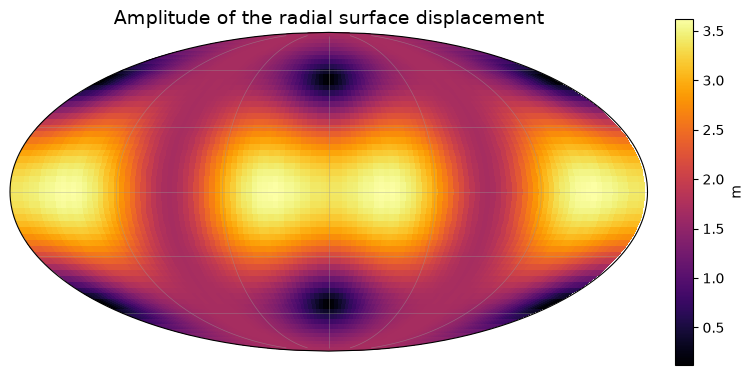

equator at longitude 0: 3.37 m, equator at longitude 90: 1.69 m, north pole: 1.68 m
largest 3.62 m at latitude 0 and longitude 330
smallest 0.12 m at latitude 53 and longitude 0


In [6]:
displacement = io.calc_3d_displacements(radii=[R], colatitudes=colatitudes, longitudes=longitudes, times=times)
radial = displacement["radial"][0]   # (colatitude, longitude, time) [m]
amplitude = 0.5 * (radial.max(axis=-1) - radial.min(axis=-1))

plot_map(longitudes, colatitudes, amplitude, title="Amplitude of the radial surface displacement", colorbar_label="m")
plt.show()
largest = np.unravel_index(np.argmax(amplitude), amplitude.shape)
smallest = np.unravel_index(np.argmin(amplitude), amplitude.shape)
print(f"equator at longitude 0: {amplitude[equator, 0]:.2f} m, "
      f"equator at longitude 90: {amplitude[equator, 30]:.2f} m, north pole: {amplitude[0, 0]:.2f} m")
for name, location in (("largest", largest), ("smallest", smallest)):
    print(f"{name} {amplitude[location]:.2f} m at latitude {90.0 - np.degrees(colatitudes[location[0]]):.0f} "
          f"and longitude {np.degrees(longitudes[location[1]]) % 360.0:.0f}")

The surface rises and falls by up to 3.6 m on the equator about 30 degrees east and west of the sub-host and anti-host meridians (3.4 m on the meridians themselves). The amplitude is approx. 1.7 m at the poles and on the equator at 90 degrees longitude. It nearly vanishes (0.12 m) near 53 degrees north and south on the sub-host and anti-host meridians.

## Faster Maps with More Threads

Every grid method takes `num_threads`. The radial solves and the per-point evaluation (over colatitude rows) run on that many threads, and the result does not depend on the thread count. The default, `num_threads = 0`, uses the number of logical processors minus 4 (at least 1). Use `num_threads = 1` inside a process or thread pool whose workers already occupy the machine.

The cell below times three grids on one thread and on every logical core. It uses harmonic degrees $l = 2$ and $3$ with eccentricity, a non-synchronous spin, and obliquity, so about a hundred tidal modes reach every point (the count is printed).

In [7]:
threads = os.cpu_count()   # Every logical core on this machine
state = dict(spin_frequency=1.2 * N_MOTION, eccentricity=0.1, obliquity=0.2)
map_radii = np.linspace(0.5 * R, 0.99 * R, 10)              # [m]
map_times = np.linspace(0.0, PERIOD, 8, endpoint=False)     # [s]

grids = {
    "Secular heating map": lambda count: io.calc_3d_tides(
        radii=map_radii, colatitudes=colatitudes, longitudes=longitudes, num_threads=count, **state)["heating"],
    "Stress and strain": lambda count: io.calc_3d_stress_strain(
        radii=map_radii, colatitudes=colatitudes, longitudes=longitudes, times=map_times[:2], num_threads=count,
        **state)["stress"],
    "Displacements": lambda count: io.calc_3d_displacements(
        radii=map_radii, colatitudes=colatitudes, longitudes=longitudes, times=map_times, num_threads=count,
        **state)["radial"],
}
with io.temporary_tide_config(min_degree_l=2, max_degree_l=3, eccentricity_truncation=10, obliquity_truncation=2):
    print(f"tidal modes: {io.calc_tides(**state)['num_tidal_modes']}")
    print(f"{'grid':20} {'1 thread':>9} {str(threads) + ' threads':>11} {'speedup':>8}  identical")
    for label, compute in grids.items():
        results, seconds = {}, {}
        for count in (1, threads):
            start = time.perf_counter()
            results[count] = compute(count)
            seconds[count] = time.perf_counter() - start
        identical = np.array_equal(results[1], results[threads], equal_nan=True)
        print(f"{label:20} {seconds[1]:8.2f}s {seconds[threads]:10.2f}s {seconds[1] / seconds[threads]:7.1f}x  "
              f"{identical}")

tidal modes: 103
grid                  1 thread  16 threads  speedup  identical


Secular heating map      0.18s       0.02s     8.2x  True


Stress and strain        0.24s       0.03s     7.6x  True


Displacements            0.19s       0.03s     7.1x  True
